# 1.- Carga de Datos

Carga de archivo **audiencias_realizadas_competencia_detalle.parquet**, consolidado de consultas mediante Api PJUD.

In [1]:
import pandas as pd

df = pd.read_parquet(r"C:\Users\frero\CD-2026-Proyecto-EquipoEMCR\data\raw\parquet\audiencias_realizadas_competencia_detalle.parquet")
df.head()

,COD_CORTE,CORTE,COD_TRIBUNAL,TRIBUNAL,RIT,TIPO_PROCEDIMIENTO,TIPO_AUDIENCIA,FECHA_INGRESO,FECHA_PROGRAMACION,FECHA_AUDIENCIA,...,HORA_FIN,ANO_AUDIENCIA,COMPETENCIA,TOTAL_AUDIENCIAS,ID_CAUSA,RUC,ID_AUDIENCIA,VIDEOCONFERENCIA,ANO_PROCESO,FECHA_FIRMA
0,30,C.A. DE VALPARAÍSO,1261,JUZGADO DE FAMILIA CASABLANCA,A-1-2015,Adopción,Audiencia Preparatoria,2015-02-06,2015-02-09,2015-02-19,...,10:24:00,2015.0,Familia,1,<NA>,NaN,<NA>,NaN,2015,NaT
1,30,C.A. DE VALPARAÍSO,1261,JUZGADO DE FAMILIA CASABLANCA,A-3-2015,Adopción,Audiencia Preparatoria,2015-06-04,2015-06-10,2015-06-17,...,11:55:00,2015.0,Familia,1,<NA>,NaN,<NA>,NaN,2015,NaT
2,30,C.A. DE VALPARAÍSO,1261,JUZGADO DE FAMILIA CASABLANCA,A-5-2015,Adopción,Audiencia de Juicio,2015-08-04,2015-09-14,2015-10-06,...,09:46:00,2015.0,Familia,1,<NA>,NaN,<NA>,NaN,2015,NaT
3,30,C.A. DE VALPARAÍSO,1261,JUZGADO DE FAMILIA CASABLANCA,A-5-2015,Adopción,Audiencia Preparatoria,2015-08-04,2015-08-14,2015-09-14,...,11:26:00,2015.0,Familia,1,<NA>,NaN,<NA>,NaN,2015,NaT
4,30,C.A. DE VALPARAÍSO,1261,JUZGADO DE FAMILIA CASABLANCA,A-6-2015,Adopción,Audiencia,2015-09-14,2015-11-18,2015-11-30,...,12:47:00,2015.0,Familia,1,<NA>,NaN,<NA>,NaN,2015,NaT


# 2.- Auditoría de Datos

Revisión técnica de la calidad, integridad y consistencia del dataset consolidado de audiencias. Comprende la verificación de dimensiones y duplicados, perfil de valores nulos, auditoría de variables categóricas, validación de variables numéricas y formatos de fecha, y visualización final de exhaustividad.

### 2.1.- Dimensión, tipos de datos y duplicados exactos

In [2]:
print("Dimensión:", df.shape)
print("\nTipos detectados por pandas:")
display(df.dtypes.to_frame("dtype"))

print("Duplicados exactos:", df.duplicated().sum())
print("Rit repetidos:", df["RIT"].duplicated().sum())

Dimensión: (466178, 22)

Tipos detectados por pandas:


,dtype
COD_CORTE,Int64
CORTE,str
COD_TRIBUNAL,Int64
TRIBUNAL,str
RIT,str
TIPO_PROCEDIMIENTO,str
TIPO_AUDIENCIA,str
FECHA_INGRESO,datetime64[ns]
FECHA_PROGRAMACION,datetime64[ns]
FECHA_AUDIENCIA,datetime64[ns]


Duplicados exactos: 0
Rit repetidos: 337777


### 2.2.- Perfil de Calidad

In [3]:
# Perfil rápido de calidad
perfil = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "% nulos": (df.isna().mean()*100).round(1),
    "n_unicos": df.nunique(dropna=True)
}).sort_values("% nulos", ascending=False)
perfil

,dtype,nulos,% nulos,n_unicos
RUC,str,422107,90.5,28969
ID_CAUSA,Int64,333977,71.6,82729
FECHA_FIRMA,datetime64[ns],292208,62.7,1109
ID_AUDIENCIA,Int64,290599,62.3,175579
VIDEOCONFERENCIA,str,248137,53.2,6
FECHA_INGRESO,datetime64[ns],43380,9.3,5324
FECHA_PROGRAMACION,datetime64[ns],8032,1.7,3540
FECHA_AUDIENCIA,datetime64[ns],1196,0.3,2933
TIPO_PROCEDIMIENTO,str,0,0.0,39
RIT,str,0,0.0,128401


### 2.3.- Auditoría de inconsistencias y frecuencias de valores

In [4]:
columnas_revision = [
    "CORTE", "TRIBUNAL", "RIT", "TIPO_PROCEDIMIENTO",
    "TIPO_AUDIENCIA", "HORA_INICIO", "HORA_FIN",
    "COMPETENCIA", "RUC", "VIDEOCONFERENCIA"
]

for col in columnas_revision:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False).head(15))


--- CORTE ---
CORTE
C.A. DE VALPARAÍSO    217057
C.A. de Valparaíso    132201
C.A. DE VALPARAISO    116920
Name: count, dtype: int64

--- TRIBUNAL ---
TRIBUNAL
JUZGADO DE FAMILIA VIÑA DEL MAR     72520
JUZGADO DE FAMILIA VALPARAÍSO       51088
JUZGADO DE FAMILIA LOS ANDES        29916
JUZGADO DE FAMILIA VILLA ALEMANA    29688
JUZGADO DE FAMILIA QUILLOTA         27403
Juzgado de Familia Valparaíso       25773
Juzgado de Familia Viña del Mar     25483
JUZGADO DE FAMILIA QUILPUE          24440
JUZGADO DE FAMILIA SAN FELIPE       21021
JUZGADO DE FAMILIA SAN ANTONIO      19119
JUZGADO DE FAMILIA LIMACHE          14776
JUZGADO DE FAMILIA CASABLANCA       13093
Juzgado de Familia Quillota         13076
Juzgado de Familia Los Andes        11985
JUZGADO DE FAMILIA LA LIGUA         11871
Name: count, dtype: int64

--- RIT ---
RIT
C-212-2024    51
C-33-2020     49
C-10-2020     46
C-181-2020    46
X-15-2016     45
X-19-2015     44
X-17-2014     44
C-304-2020    44
X-41-2015     43
X-93-2015    

### 2.4.- Auditoría de columnas numéricas y consistencia de fechas (datetime64[ns])

In [5]:
# 1. Auditoría de columnas numéricas (Int64, int64, float64)
cols_numericas = df.select_dtypes(include=['number']).columns.tolist()

resumen_num = pd.DataFrame({
    'dtype': df[cols_numericas].dtypes.astype(str),
    'nulos': df[cols_numericas].isna().sum(),
    'min': df[cols_numericas].min(),
    'max': df[cols_numericas].max(),
    'valores_unicos': df[cols_numericas].nunique(),
    'tiene_decimales': [
        (df[c].dropna() % 1 != 0).any() if df[c].dtype == 'float64' else False
        for c in cols_numericas
    ]
})

print("=== RESUMEN DE VARIABLES NUMÉRICAS ===")
display(resumen_num)

# 2. Auditoría de columnas datetime64[ns]
cols_fechas = df.select_dtypes(include=['datetime64[ns]']).columns.tolist()

resumen_fechas = []
for col in cols_fechas:
    serie = df[col].dropna()
    tiene_hora = (serie.dt.hour != 0) | (serie.dt.minute != 0) | (serie.dt.second != 0)
    resumen_fechas.append({
        'columna': col,
        'dtype': str(df[col].dtype),
        'nulos': df[col].isna().sum(),
        '% nulos': round(df[col].isna().mean() * 100, 2),
        'fecha_min': serie.min(),
        'fecha_max': serie.max(),
        'tiene_horas': tiene_hora.any(),
        'ejemplo_iso': str(serie.iloc[0]) if len(serie) > 0 else 'N/A'
    })

print("\n=== RESUMEN DE VARIABLES DE FECHA (datetime64[ns]) ===")
display(pd.DataFrame(resumen_fechas))

# 3. Muestra de fechas en formato ISO y formato dd-mm-aaaa
print("\n=== COMPARACIÓN DE FORMATO: ISO (estándar pandas) vs DD-MM-AAAA ===")
fechas_muestra = df[cols_fechas].dropna().head(5)
display(fechas_muestra)

print("\nRepresentación explícita en dd-mm-aaaa:")
display(fechas_muestra.apply(lambda s: s.dt.strftime('%d-%m-%Y')))

=== RESUMEN DE VARIABLES NUMÉRICAS ===


,dtype,nulos,min,max,valores_unicos,tiene_decimales
COD_CORTE,Int64,0,30.0,30.0,1,False
COD_TRIBUNAL,Int64,0,88.0,1271.0,15,False
PLAZO_AGENDAMIENTO,float64,97,-6.0,339.0,253,False
ANO_AUDIENCIA,float64,0,2015.0,2025.0,11,False
TOTAL_AUDIENCIAS,Int64,0,1.0,2.0,2,False
ID_CAUSA,Int64,333977,275301.0,14082680.0,82729,False
ID_AUDIENCIA,Int64,290599,869051.0,11788789.0,175579,False
ANO_PROCESO,int64,0,2015.0,2025.0,11,False



=== RESUMEN DE VARIABLES DE FECHA (datetime64[ns]) ===


,columna,dtype,nulos,% nulos,fecha_min,fecha_max,tiene_horas,ejemplo_iso
0,FECHA_INGRESO,datetime64[ns],43380,9.31,2005-10-19,2025-12-30,False,2015-02-06 00:00:00
1,FECHA_PROGRAMACION,datetime64[ns],8032,1.72,2006-06-08,2025-12-30,False,2015-02-09 00:00:00
2,FECHA_AUDIENCIA,datetime64[ns],1196,0.26,2015-01-02,2025-12-31,False,2015-02-19 00:00:00
3,FECHA_FIRMA,datetime64[ns],292208,62.68,2020-12-03,2024-12-31,False,2021-01-06 00:00:00



=== COMPARACIÓN DE FORMATO: ISO (estándar pandas) vs DD-MM-AAAA ===


,FECHA_INGRESO,FECHA_PROGRAMACION,FECHA_AUDIENCIA,FECHA_FIRMA
248233,2019-12-12,2020-08-21,2021-01-25,2021-01-27
248234,2019-10-17,2020-09-08,2021-01-04,2021-01-05
248235,2019-12-10,2020-09-08,2021-01-07,2021-01-08
248236,2020-04-08,2020-09-10,2021-01-12,2021-01-14
248237,2020-07-16,2020-09-11,2021-01-11,2021-01-11



Representación explícita en dd-mm-aaaa:


,FECHA_INGRESO,FECHA_PROGRAMACION,FECHA_AUDIENCIA,FECHA_FIRMA
248233,12-12-2019,21-08-2020,25-01-2021,27-01-2021
248234,17-10-2019,08-09-2020,04-01-2021,05-01-2021
248235,10-12-2019,08-09-2020,07-01-2021,08-01-2021
248236,08-04-2020,10-09-2020,12-01-2021,14-01-2021
248237,16-07-2020,11-09-2020,11-01-2021,11-01-2021


### 2.5.- Visualización de % Nulos por Columna

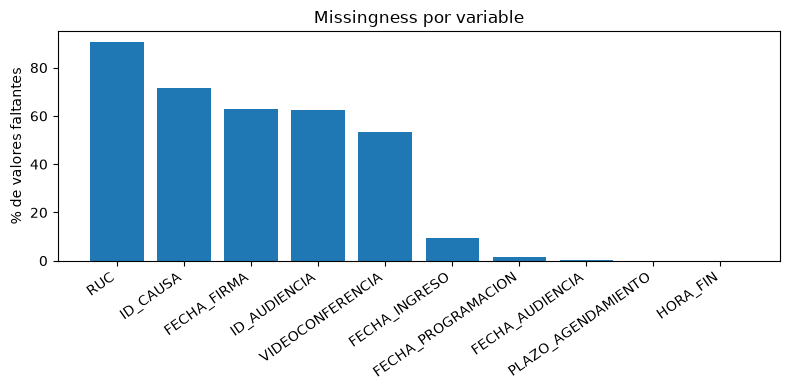

In [6]:
import matplotlib.pyplot as plt

missing = df.isna().mean().sort_values(ascending=False) * 100
missing = missing[missing > 0]

plt.figure(figsize=(8, 4))
plt.bar(missing.index, missing.values)
plt.ylabel("% de valores faltantes")
plt.xticks(rotation=35, ha="right")
plt.title("Missingness por variable")
plt.tight_layout()
plt.show()